#### 1. Load the dataset and preprocess (missing values, outliers, normalization)


In [30]:
import pandas as pd
# .values give only raw data no column names
pd.read_csv("adult.csv")["age"].dropna().values

array([25, 38, 28, ..., 58, 22, 52])

In [ ]:
####x 1. Load the dataset and preprocess (missing values, outliers, normalization)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("adult.csv")    # replace with your CSV file
x = df["age"].dropna().values   # choose numeric column

# Compute quantiles
q1 = np.quantile(x, 0.25)  # 25th percentile
q2 = np.quantile(x, 0.50)  # median
q3 = np.quantile(x, 0.75)  # 75th percentile

print(f"Q1 (25th percentile): {q1}")
print(f"Q2 (Median, 50th percentile): {q2}")
print(f"Q3 (75th percentile): {q3}")

### Step 2: Remove outliers using the IQR (Interquartile Range)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Keep only values within bounds
x_no_outliers = x[(x >= lower_bound) & (x <= upper_bound)]
print(f"Number of data points after outlier removal: {len(x_no_outliers)}")

### Step 3: Normalize the data (z-score)
x_norm = (x_no_outliers - np.mean(x_no_outliers)) / np.std(x_no_outliers)
x_norm[:10]  # preview first 10 normalized values



Q1 (25th percentile): 28.0
Q2 (Median, 50th percentile): 37.0
Q3 (75th percentile): 48.0
Number of data points after outlier removal: 48626


array([-1.00289765, -0.03309496, -0.77909703,  0.41450628, -1.5250991 ,
       -0.33149579, -0.70449683,  1.83191021, -1.07749786,  1.23510856])

Histogram

In [37]:
(x_no_outliers - x_no_outliers.mean()) / x_no_outliers.std()

array([-1.00289765, -0.03309496, -0.77909703, ...,  1.45890918,
       -1.22669827,  1.01130794])

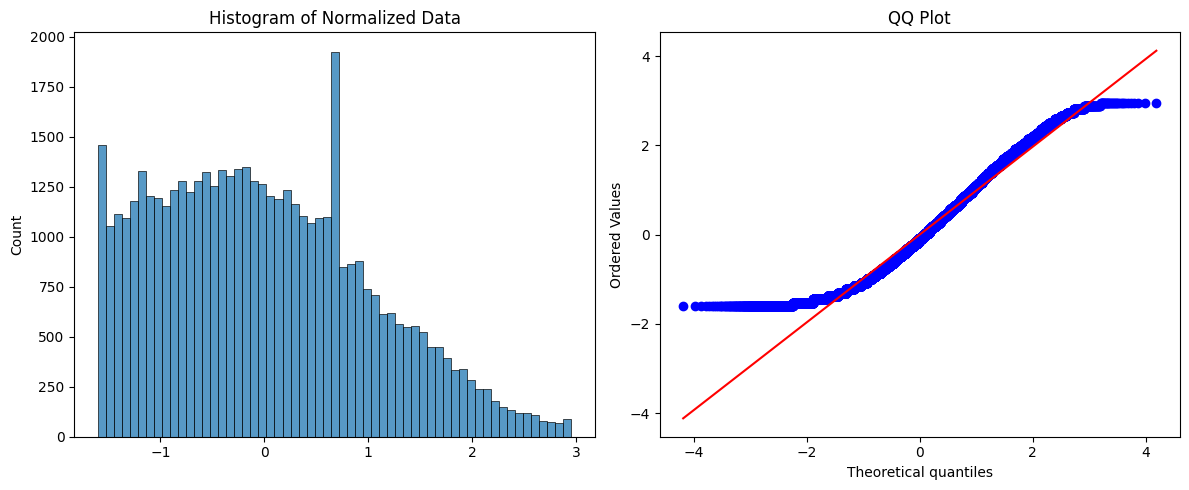

In [38]:
# Histogram
from scipy import stats


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(x_norm)
plt.title("Histogram of Normalized Data")

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(x_norm, plot=plt)
plt.title("QQ Plot")

plt.tight_layout()
plt.show()


Shapiro-Wilk *Test*

In [34]:
# Shapiro-Wilk Test
shapiro_test = stats.shapiro(x_norm)
print(f"Shapiro-Wilk Test: Statistic={shapiro_test.statistic}, p-value={shapiro_test.pvalue}")

# Kolmogorov-Smirnov Test
ks_test = stats.kstest(x_norm, 'norm', args=(np.mean(x_norm), np.std(x_norm)))
print(f"K-S Test: Statistic={ks_test.statistic}, p-value={ks_test.pvalue}")


Shapiro-Wilk Test: Statistic=0.9682389285395746, p-value=9.657923243917013e-70
K-S Test: Statistic=0.06292041403985604, p-value=8.407992094206501e-168


/Users/mohitreddy/Library/CloudStorage/GoogleDrive-mohit2310893@ssn.edu.in/My Drive/sem_5/Data Analytics lab/venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 48626.
  res = hypotest_fun_out(*samples, **kwds)


### Q4. What if the data is not normally distributed?  

**Answer:**  
We can try transformations to make it more Gaussian:  
- **Log transform** (for positive data)  
- **Box-Cox transform** (positive data, with lambda optimization)  
- **Yeo-Johnson transform** (works for negatives too)  
Then we re-check histogram, QQ plot, and tests.


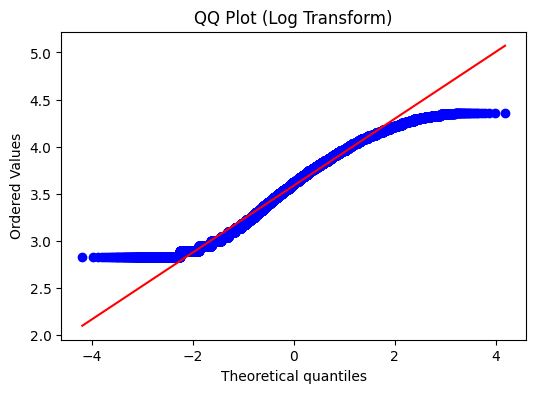

Shapiro-Wilk (Log): stat=0.9809, p=0.0000


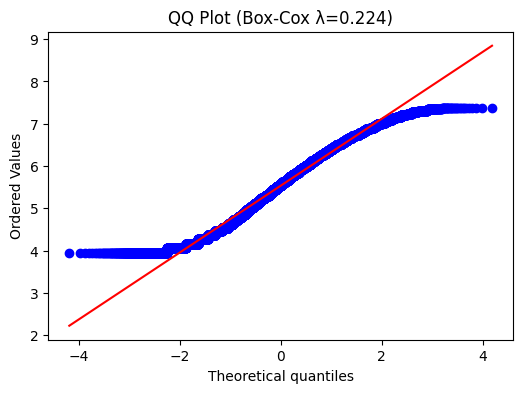

Shapiro-Wilk (Box-Cox): stat=0.9835, p=0.0000


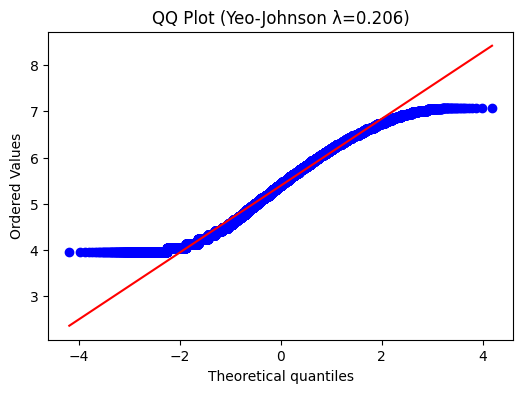

Shapiro-Wilk (Yeo-Johnson): stat=0.9834, p=0.0000


In [35]:
# QA: Apply transformations (log, Box-Cox, Yeo-Johnson) to make data more Gaussian
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Assuming `x_no_outliers` is your cleaned numeric data

# 1️⃣ Log Transform (only positive values)
if np.all(x_no_outliers > 0):
    x_log = np.log(x_no_outliers)
    plt.figure(figsize=(6,4))
    stats.probplot(x_log, dist="norm", plot=plt)
    plt.title("QQ Plot (Log Transform)")
    plt.show()
    shapiro_log_stat, shapiro_log_p = stats.shapiro(x_log)
    print(f"Shapiro-Wilk (Log): stat={shapiro_log_stat:.4f}, p={shapiro_log_p:.4f}")

# 2️⃣ Box-Cox Transform (positive values only)
if np.all(x_no_outliers > 0):
    x_boxcox, lmbda_boxcox = stats.boxcox(x_no_outliers)
    plt.figure(figsize=(6,4))
    stats.probplot(x_boxcox, dist="norm", plot=plt)
    plt.title(f"QQ Plot (Box-Cox λ={lmbda_boxcox:.3f})")
    plt.show()
    shapiro_boxcox_stat, shapiro_boxcox_p = stats.shapiro(x_boxcox)
    print(f"Shapiro-Wilk (Box-Cox): stat={shapiro_boxcox_stat:.4f}, p={shapiro_boxcox_p:.4f}")

# 3️⃣ Yeo-Johnson Transform (handles negatives too)
x_yj, lmbda_yj = stats.yeojohnson(x_no_outliers)
plt.figure(figsize=(6,4))
stats.probplot(x_yj, dist="norm", plot=plt)
plt.title(f"QQ Plot (Yeo-Johnson λ={lmbda_yj:.3f})")
plt.show()
shapiro_yj_stat, shapiro_yj_p = stats.shapiro(x_yj)
print(f"Shapiro-Wilk (Yeo-Johnson): stat={shapiro_yj_stat:.4f}, p={shapiro_yj_p:.4f}")


Re-evaluate transformed data

NameError: name 'boxcox_data' is not defined

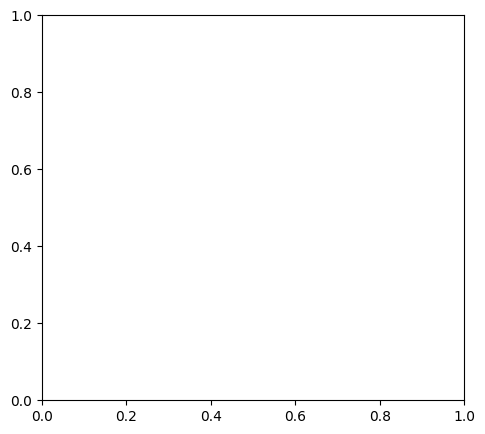

In [39]:
# Histogram and QQ plot for Box-Cox
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(boxcox_data, bins=30, color='lightgreen', edgecolor='black')
plt.title("Histogram of Box-Cox Transformed Data")

plt.subplot(1, 2, 2)
stats.probplot(boxcox_data, dist="norm", plot=plt)
plt.title("QQ Plot (Box-Cox Transformed)")

plt.tight_layout()
plt.show()

# Re-run normality tests
print("After Box-Cox Transformation:")
print(f"Shapiro-Wilk: {stats.shapiro(boxcox_data)}")
print(f"K-S Test: {stats.kstest(boxcox_data, 'norm', args=(np.mean(boxcox_data), np.std(boxcox_data)))}")


#### 6. Findings and implications
- If **p > 0.05**, we fail to reject normality → data is approximately normal.  
- If **p < 0.05**, data is not normal → transformations may help.  
- Normal data allows **parametric tests and linear models**.  
- Non-normal data may require **non-parametric tests** (Mann–Whitney, Kruskal–Wallis) or transformations before modeling.  
